In [96]:
# =========================
# CELDA 1 - INSTALL + IMPORTS
# =========================
!pip -q install ultralytics joblib

import os, random
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image

import joblib

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, cohen_kappa_score

import matplotlib.pyplot as plt
import seaborn as sns

from ultralytics import YOLO

print("✅ Imports OK")


✅ Imports OK



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [98]:
# =========================
# CELDA 2 - CONFIG GENERAL + SELECCIÓN DE ENSEMBLE
# =========================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

# CSVs
TRAIN_CSV_PATH = "../Datos/Train_clean.csv"
TEST_CSV_PATH  = "../Datos/Test_clean.csv"

# Carpeta raíz de imágenes
IMAGES_ROOT = "../Datos/images/MULTICLASE"

# Tabular
N_SPLITS = 5
MAX_IMAGES_PER_ROW = 5

# RandomForest
RF_N_EST = 400
RF_MAX_DEPTH = 20

# Gate (LogReg)
GATE_C = 1.0
GATE_MAX_ITER = 2000
GATE_THRESHOLD = 0.5  # P(gate=1) >= umbral -> consulta imagen

# Fusión cuando gate=1
ALPHA_IMG = 0.5

# Imagen
IMG_SIZE = 224

# Nombres de clase (si son 6 o 2)
class_names_multiclass = ["ACK","BCC","MEL","NEV","SCC","SEK"]
class_names_binario    = ["Benigno","Maligno"]

# ---------------------------------------------------------
# 🔥 AQUÍ defines qué modelos de imagen quieres usar
# ---------------------------------------------------------
# Cada entrada:
# - kind: "resnet18" | "densenet121" | "yolo_cls"
# - weight: peso del soft-voting global (se normaliza solo)
# - paths: lista de checkpoints (folds) para ese tipo de modelo
IMG_ENSEMBLE_SPECS = [
    {
        "kind": "resnet18",
        "weight": 1,
        "paths": [
            "../DAVID/final/ResNet18_5Fold_fold1.pth",
            "../DAVID/final/ResNet18_5Fold_fold2.pth",
            "../DAVID/final/ResNet18_5Fold_fold3.pth",
            "../DAVID/final/ResNet18_5Fold_fold4.pth",
            "../DAVID/final/ResNet18_5Fold_fold5.pth"
        ],
    },
    # {
    #     "kind": "densenet121",
    #     "weight": 0,
    #     "paths": [
    #         "../DAVID/final_binario/DenseNet121_Binario_5Fold_fold1.pth",
    #         "../DAVID/final_binario/DenseNet121_Binario_5Fold_fold2.pth",
    #         "../DAVID/final_binario/DenseNet121_Binario_5Fold_fold3.pth",
    #         "../DAVID/final_binario/DenseNet121_Binario_5Fold_fold4.pth",
    #         "../DAVID/final_binario/DenseNet121_Binario_5Fold_fold5.pth"
    #     ],
    # },
    # {
    #     "kind": "yolo_cls",
    #     "weight": 0,
    #     "paths": [
    #         "../DAVID/final_binario/runs/classify/runs/YOLO26x_CV/fold_1/weights/best.pt",
    #         "../DAVID/final_binario/runs/classify/runs/YOLO26x_CV/fold_2/weights/best.pt",
    #         "../DAVID/final_binario/runs/classify/runs/YOLO26x_CV/fold_3/weights/best.pt",
    #         "../DAVID/final_binario/runs/classify/runs/YOLO26x_CV/fold_4/weights/best.pt",
    #         "../DAVID/final_binario/runs/classify/runs/YOLO26x_CV/fold_5/weights/best.pt"
    #     ],
    # },
]

print("✅ Config OK")


DEVICE: cpu
✅ Config OK


In [99]:
# =========================
# CELDA 3 - CARGA DATA + TABULAR PREP
# =========================
train_df = pd.read_csv(TRAIN_CSV_PATH)
test_df  = pd.read_csv(TEST_CSV_PATH)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

LABEL_COL = "diagnostic"
assert LABEL_COL in train_df.columns
assert "img_id" in train_df.columns

EXCLUDE_COLS = set(["img_id","patient_id","lesion_id","patient_lesion_id","img_path",'diagnostic_binario', LABEL_COL])
tab_cols = [c for c in train_df.columns if c not in EXCLUDE_COLS]

train_df[tab_cols] = train_df[tab_cols].fillna(0)
test_df[tab_cols]  = test_df[tab_cols].fillna(0)

y_train = train_df[LABEL_COL].astype(int).values
y_test  = test_df[LABEL_COL].astype(int).values

NUM_CLASSES = len(np.unique(y_train))

if NUM_CLASSES == 2:
    class_names = class_names_binario
elif NUM_CLASSES == 6:
    class_names = class_names_multiclass
else:
    class_names = [f"Clase_{i}" for i in range(NUM_CLASSES)]

print("✅ NUM_CLASSES:", NUM_CLASSES)
print("✅ class_names:", class_names)
print("Distribución Train:", pd.Series(y_train).value_counts().sort_index().to_dict())

scaler = StandardScaler()
Xtab_train = scaler.fit_transform(train_df[tab_cols].values.astype(np.float32))
Xtab_test  = scaler.transform(test_df[tab_cols].values.astype(np.float32))

print("Xtab_train:", Xtab_train.shape, "| Xtab_test:", Xtab_test.shape)


Train shape: (566, 89)
Test shape : (142, 89)
✅ NUM_CLASSES: 6
✅ class_names: ['ACK', 'BCC', 'MEL', 'NEV', 'SCC', 'SEK']
Distribución Train: {0: 115, 1: 117, 2: 29, 3: 104, 4: 96, 5: 105}
Xtab_train: (566, 83) | Xtab_test: (142, 83)


In [100]:
# =========================
# CELDA 4 - INDEXADO DE IMÁGENES + HELPERS
# =========================
def parse_img_list(s, max_images=5):
    if pd.isna(s):
        return []
    if isinstance(s, str):
        parts = [p.strip() for p in s.split(",") if p.strip()]
        return parts[:max_images]
    return []

print("🔎 Indexando imágenes en:", IMAGES_ROOT)

img_index = {}
total = 0
for root, _, files in os.walk(IMAGES_ROOT):
    for f in files:
        if f.lower().endswith((".png",".jpg",".jpeg",".bmp",".webp")):
            total += 1
            img_index[f] = os.path.join(root, f)

print("✅ Total imágenes:", total, "| indexadas:", len(img_index))

def row_img_paths(df, i):
    fns = parse_img_list(df.loc[i, "img_id"], MAX_IMAGES_PER_ROW)
    return [img_index[fn] for fn in fns if fn in img_index]

def coverage(df):
    tot, miss = 0, 0
    for s in df["img_id"].astype(str).values:
        for fn in parse_img_list(s, MAX_IMAGES_PER_ROW):
            tot += 1
            if fn not in img_index:
                miss += 1
    return tot, miss

tr_tot, tr_miss = coverage(train_df)
te_tot, te_miss = coverage(test_df)
print(f"Train refs {tr_tot} | miss {tr_miss} | cov {(1-tr_miss/max(1,tr_tot))*100:.2f}%")
print(f"Test  refs {te_tot} | miss {te_miss} | cov {(1-te_miss/max(1,te_tot))*100:.2f}%")


🔎 Indexando imágenes en: ../Datos/images/MULTICLASE
✅ Total imágenes: 802 | indexadas: 802
Train refs 649 | miss 0 | cov 100.00%
Test  refs 153 | miss 0 | cov 100.00%


In [101]:
# =========================
# CELDA 5 - MODELOS DE IMAGEN (GENERAL): load + predict probs (ROBUSTO A HEADS)
# =========================
img_tf_eval = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

def softvote_mean(probs_list, num_classes):
    if len(probs_list) == 0:
        return np.ones(num_classes, dtype=np.float32) / num_classes
    return np.mean(np.stack(probs_list, axis=0), axis=0)

def weighted_softvote(probs_list, weights, num_classes):
    if len(probs_list) == 0:
        return np.ones(num_classes, dtype=np.float32) / num_classes
    w = np.asarray(weights, dtype=np.float32)
    w = np.clip(w, 0.0, None)
    if w.sum() <= 0:
        w = np.ones_like(w)
    w = w / w.sum()
    P = np.stack(probs_list, axis=0)  # (M,C)
    return (P * w[:, None]).sum(axis=0)

# --------- Builders ---------
def build_resnet18(num_classes, head_kind="linear"):
    """
    head_kind:
      - "linear": fc = Linear
      - "seq_drop_linear": fc = Sequential(Dropout, Linear)
      - "seq_linear_drop": fc = Sequential(Linear, Dropout)  (raro, pero por completitud)
    """
    m = models.resnet18(weights=None)
    in_f = m.fc.in_features
    if head_kind == "linear":
        m.fc = nn.Linear(in_f, num_classes)
    elif head_kind == "seq_drop_linear":
        m.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(in_f, num_classes))
    elif head_kind == "seq_linear_drop":
        m.fc = nn.Sequential(nn.Linear(in_f, num_classes), nn.Dropout(0.5))
    else:
        raise ValueError(f"Unknown head_kind: {head_kind}")
    return m

def build_densenet121(num_classes, head_kind="linear"):
    """
    head_kind:
      - "linear": classifier = Linear
      - "seq_drop_linear": classifier = Sequential(Dropout, Linear)
    """
    m = models.densenet121(weights=None)
    in_f = m.classifier.in_features
    if head_kind == "linear":
        m.classifier = nn.Linear(in_f, num_classes)
    elif head_kind == "seq_drop_linear":
        m.classifier = nn.Sequential(nn.Dropout(0.5), nn.Linear(in_f, num_classes))
    else:
        raise ValueError(f"Unknown head_kind: {head_kind}")
    return m

def _detect_head_resnet(state):
    keys = state.keys()
    # casos típicos
    if ("fc.weight" in keys) and ("fc.bias" in keys):
        return "linear"
    if ("fc.1.weight" in keys) and ("fc.1.bias" in keys):
        return "seq_drop_linear"    # Dropout=0, Linear=1
    if ("fc.0.weight" in keys) and ("fc.0.bias" in keys):
        # puede ser linear (si se guardó como fc.0 pero realmente era Sequential con Linear en 0)
        # en la práctica suele ser Sequential(Linear, ...) o algún wrapper.
        return "seq_linear_drop"    # asumimos Linear=0
    return "linear"

def _detect_head_densenet(state):
    keys = state.keys()
    if ("classifier.weight" in keys) and ("classifier.bias" in keys):
        return "linear"
    if ("classifier.1.weight" in keys) and ("classifier.1.bias" in keys):
        return "seq_drop_linear"
    if ("classifier.0.weight" in keys) and ("classifier.0.bias" in keys):
        # análogo al caso resnet
        return "linear"  # o seq_linear_drop (no lo definimos aquí porque DenseNet no suele llevar dropout después)
    return "linear"

def _remap_resnet_fc_keys_if_needed(state, head_kind):
    """
    Si construimos seq_drop_linear pero el checkpoint trae fc.weight,
    remapea a fc.1.weight / fc.1.bias, etc.
    """
    state = dict(state)  # copia
    keys = list(state.keys())

    if head_kind == "seq_drop_linear":
        # ckpt linear -> seq_drop_linear
        if ("fc.weight" in keys) and ("fc.1.weight" not in keys):
            state["fc.1.weight"] = state.pop("fc.weight")
            state["fc.1.bias"]   = state.pop("fc.bias")
        # ckpt fc.0 -> seq_drop_linear
        if ("fc.0.weight" in keys) and ("fc.1.weight" not in keys):
            state["fc.1.weight"] = state.pop("fc.0.weight")
            state["fc.1.bias"]   = state.pop("fc.0.bias")

    elif head_kind == "linear":
        # ckpt seq_drop_linear -> linear
        if ("fc.1.weight" in keys) and ("fc.weight" not in keys):
            state["fc.weight"] = state.pop("fc.1.weight")
            state["fc.bias"]   = state.pop("fc.1.bias")
        # ckpt fc.0 -> linear
        if ("fc.0.weight" in keys) and ("fc.weight" not in keys):
            state["fc.weight"] = state.pop("fc.0.weight")
            state["fc.bias"]   = state.pop("fc.0.bias")

    elif head_kind == "seq_linear_drop":
        # queremos Linear en fc.0.*
        if ("fc.weight" in keys) and ("fc.0.weight" not in keys):
            state["fc.0.weight"] = state.pop("fc.weight")
            state["fc.0.bias"]   = state.pop("fc.bias")
        if ("fc.1.weight" in keys) and ("fc.0.weight" not in keys):
            state["fc.0.weight"] = state.pop("fc.1.weight")
            state["fc.0.bias"]   = state.pop("fc.1.bias")

    return state

def _remap_densenet_classifier_keys_if_needed(state, head_kind):
    state = dict(state)
    keys = list(state.keys())

    if head_kind == "seq_drop_linear":
        if ("classifier.weight" in keys) and ("classifier.1.weight" not in keys):
            state["classifier.1.weight"] = state.pop("classifier.weight")
            state["classifier.1.bias"]   = state.pop("classifier.bias")
        if ("classifier.0.weight" in keys) and ("classifier.1.weight" not in keys):
            state["classifier.1.weight"] = state.pop("classifier.0.weight")
            state["classifier.1.bias"]   = state.pop("classifier.0.bias")

    elif head_kind == "linear":
        if ("classifier.1.weight" in keys) and ("classifier.weight" not in keys):
            state["classifier.weight"] = state.pop("classifier.1.weight")
            state["classifier.bias"]   = state.pop("classifier.1.bias")
        if ("classifier.0.weight" in keys) and ("classifier.weight" not in keys):
            state["classifier.weight"] = state.pop("classifier.0.weight")
            state["classifier.bias"]   = state.pop("classifier.0.bias")

    return state

def load_torch_ensemble(kind, paths, num_classes):
    models_list = []
    for pth in paths:
        state = torch.load(pth, map_location="cpu")
        if isinstance(state, dict) and "state_dict" in state:
            state = state["state_dict"]  # por si guardaste un checkpoint tipo lightning

        if kind == "resnet18":
            head_kind = _detect_head_resnet(state)
            m = build_resnet18(num_classes, head_kind=head_kind)
            state2 = _remap_resnet_fc_keys_if_needed(state, head_kind)
        elif kind == "densenet121":
            head_kind = _detect_head_densenet(state)
            m = build_densenet121(num_classes, head_kind=head_kind)
            state2 = _remap_densenet_classifier_keys_if_needed(state, head_kind)
        else:
            raise ValueError(f"Unknown torch kind: {kind}")

        # Carga estricta después de remap
        m.load_state_dict(state2, strict=True)
        m.to(DEVICE).eval()
        models_list.append(m)

        print(f"✅ Loaded {kind} ckpt={os.path.basename(pth)} | head={head_kind}")

    return models_list

def load_yolo_ensemble(paths):
    return [YOLO(p) for p in paths]

@torch.no_grad()
def torch_probs_single_image(models_list, pil_img, num_classes):
    x = img_tf_eval(pil_img).unsqueeze(0).to(DEVICE)
    probs = []
    for m in models_list:
        out = m(x)
        pr = torch.softmax(out, dim=1).squeeze(0).cpu().numpy().astype(np.float32)
        probs.append(pr)
    return softvote_mean(probs, num_classes)

def yolo_probs_single_image(yolo_models, pil_img, num_classes):
    probs = []
    for ym in yolo_models:
        r = ym.predict(pil_img, imgsz=IMG_SIZE, verbose=False)
        pr = r[0].probs.data.detach().cpu().numpy().astype(np.float32)
        probs.append(pr)
    return softvote_mean(probs, num_classes)

def safe_open_rgb(path):
    try:
        return Image.open(path).convert("RGB")
    except:
        return Image.new("RGB", (IMG_SIZE, IMG_SIZE))

def normalize_model_weights(specs):
    ws = np.array([float(s.get("weight", 1.0)) for s in specs], dtype=np.float32)
    ws = np.clip(ws, 0.0, None)
    if ws.sum() <= 0:
        ws = np.ones_like(ws)
    return ws / ws.sum()

class ImageEnsemble:
    def __init__(self, specs, num_classes):
        self.num_classes = num_classes
        self.specs = [s for s in specs if len(s.get("paths", [])) > 0]
        self.weights = normalize_model_weights(self.specs)

        self.blocks = []
        for s in self.specs:
            kind = s["kind"]
            paths = s["paths"]
            if kind in ("resnet18", "densenet121"):
                mdl = load_torch_ensemble(kind, paths, num_classes)
            elif kind == "yolo_cls":
                mdl = load_yolo_ensemble(paths)
            else:
                raise ValueError(f"Unknown kind: {kind}")
            self.blocks.append((kind, mdl))

        print("✅ ImageEnsemble listo:")
        for (w, s) in zip(self.weights, self.specs):
            print(f"  - {s['kind']} | n_ckpt={len(s['paths'])} | weight={w:.3f}")

    def probs_for_pil(self, pil_img):
        per_model_probs = []
        for (kind, mdl) in self.blocks:
            if kind in ("resnet18", "densenet121"):
                pr = torch_probs_single_image(mdl, pil_img, self.num_classes)
            elif kind == "yolo_cls":
                pr = yolo_probs_single_image(mdl, pil_img, self.num_classes)
            else:
                raise ValueError(kind)
            per_model_probs.append(pr)
        return weighted_softvote(per_model_probs, self.weights, self.num_classes)

    def probs_for_paths(self, img_paths):
        probs_imgs = []
        for p in img_paths:
            im = safe_open_rgb(p)
            probs_imgs.append(self.probs_for_pil(im))
        return softvote_mean(probs_imgs, self.num_classes)

img_ens = ImageEnsemble(IMG_ENSEMBLE_SPECS, NUM_CLASSES)


✅ Loaded resnet18 ckpt=ResNet18_5Fold_fold1.pth | head=seq_drop_linear
✅ Loaded resnet18 ckpt=ResNet18_5Fold_fold2.pth | head=seq_drop_linear
✅ Loaded resnet18 ckpt=ResNet18_5Fold_fold3.pth | head=seq_drop_linear
✅ Loaded resnet18 ckpt=ResNet18_5Fold_fold4.pth | head=seq_drop_linear
✅ Loaded resnet18 ckpt=ResNet18_5Fold_fold5.pth | head=seq_drop_linear
✅ ImageEnsemble listo:
  - resnet18 | n_ckpt=5 | weight=1.000


In [102]:
# =========================
# CELDA 6 - OOF TABULAR (RF) + TARGET PARA GATE
# =========================
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_proba_tab = np.zeros((len(train_df), NUM_CLASSES), dtype=np.float32)
oof_pred_tab  = np.zeros((len(train_df),), dtype=int)

print("🚀 Generando OOF del RF...")

for fold, (tr_idx, va_idx) in enumerate(skf.split(Xtab_train, y_train), start=1):
    print(f"\nFOLD {fold}/{N_SPLITS}")

    rf = RandomForestClassifier(
        n_estimators=RF_N_EST,
        max_depth=RF_MAX_DEPTH,
        random_state=SEED,
        n_jobs=-1
    )
    rf.fit(Xtab_train[tr_idx], y_train[tr_idx])

    proba = rf.predict_proba(Xtab_train[va_idx])
    pred  = np.argmax(proba, axis=1)

    oof_proba_tab[va_idx] = proba
    oof_pred_tab[va_idx]  = pred

# Gate target: 1 si RF falla
target_gate = (oof_pred_tab != y_train).astype(int)

print("\n✅ OOF listo.")
print("OOF RF Accuracy:", accuracy_score(y_train, oof_pred_tab))
print("OOF RF F1-macro:", f1_score(y_train, oof_pred_tab, average="macro"))
print("Gate target (1=RF falla) ratio:", target_gate.mean())


🚀 Generando OOF del RF...

FOLD 1/5

FOLD 2/5

FOLD 3/5

FOLD 4/5

FOLD 5/5

✅ OOF listo.
OOF RF Accuracy: 0.6307420494699647
OOF RF F1-macro: 0.6127407588213972
Gate target (1=RF falla) ratio: 0.36925795053003535


In [103]:
# =========================
# CELDA 7 - FEATURES PARA GATE (desde incertidumbre tabular)
# =========================
def entropy(p, eps=1e-12):
    p = np.clip(p, eps, 1.0)
    return -np.sum(p * np.log(p), axis=1)

p = oof_proba_tab
max_prob = p.max(axis=1)
sorted_p = np.sort(p, axis=1)
margin = sorted_p[:, -1] - sorted_p[:, -2]
ent = entropy(p)

X_gate = np.vstack([max_prob, margin, ent]).T  # (N,3)

print("✅ Gate features:", X_gate.shape)
print("Ejemplo primeras filas:\n", X_gate[:5])


✅ Gate features: (566, 3)
Ejemplo primeras filas:
 [[      0.705        0.57      1.0139]
 [       0.52        0.25      1.1581]
 [       0.43         0.1      1.1919]
 [     0.3975      0.0625      1.3851]
 [     0.5975        0.25     0.88382]]


In [104]:
# =========================
# CELDA 8 - ENTRENAR GATE (LogReg)
# =========================
gate = LogisticRegression(
    C=GATE_C,
    max_iter=GATE_MAX_ITER,
    class_weight="balanced",
    solver="lbfgs",      # multiclass OK
    multi_class="auto"
)

gate.fit(X_gate, target_gate)
print("✅ Gate entrenada (LogReg)")

gate_pred = (gate.predict_proba(X_gate)[:,1] >= GATE_THRESHOLD).astype(int)
print("Gate pred ratio:", gate_pred.mean())
print("Gate accuracy vs target:", accuracy_score(target_gate, gate_pred))


✅ Gate entrenada (LogReg)
Gate pred ratio: 0.5141342756183745
Gate accuracy vs target: 0.6643109540636042


In [105]:
# =========================
# CELDA 9 - ENTRENAR RF FINAL TABULAR
# =========================
rf_final = RandomForestClassifier(
    n_estimators=RF_N_EST,
    max_depth=RF_MAX_DEPTH,
    random_state=SEED,
    n_jobs=-1
)
rf_final.fit(Xtab_train, y_train)
print("✅ RF final entrenado")


✅ RF final entrenado


BASELINE TABULAR (RF SOLO)
Accuracy: 0.6830985915492958
F1-macro: 0.6505635840599235
Kappa   : 0.6084798725568286

Classification report:
              precision    recall  f1-score   support

         ACK     0.6970    0.7931    0.7419        29
         BCC     0.5882    0.6667    0.6250        30
         MEL     1.0000    0.2857    0.4444         7
         NEV     0.6786    0.7308    0.7037        26
         SCC     0.6522    0.6250    0.6383        24
         SEK     0.8182    0.6923    0.7500        26

    accuracy                         0.6831       142
   macro avg     0.7390    0.6323    0.6506       142
weighted avg     0.7002    0.6831    0.6795       142



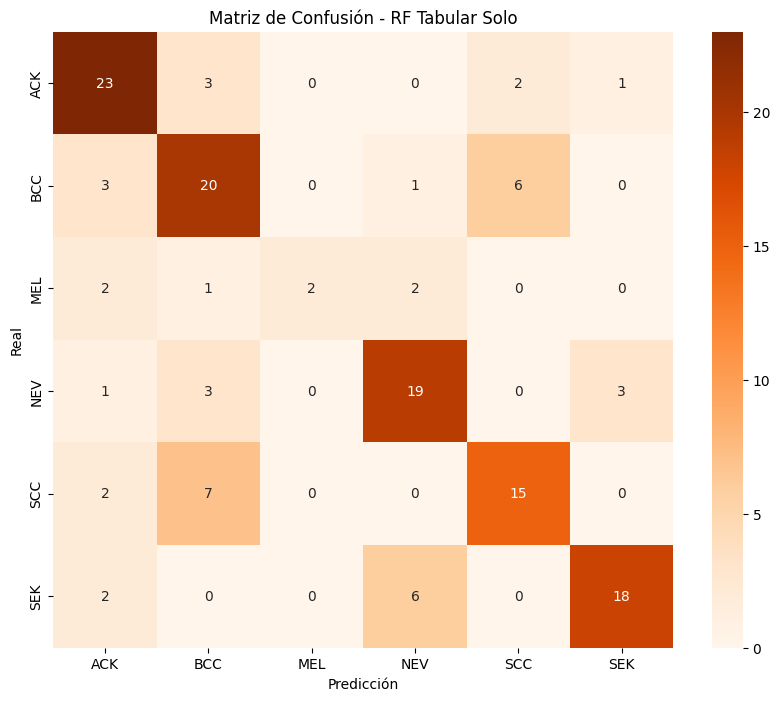

In [106]:
# =========================
# CELDA 10 - EVALUACIÓN TABULAR BASELINE (RF SOLO)
# =========================
p_tab_test = rf_final.predict_proba(Xtab_test)
pred_tab_test = np.argmax(p_tab_test, axis=1)

print("="*60)
print("BASELINE TABULAR (RF SOLO)")
print("="*60)
print("Accuracy:", accuracy_score(y_test, pred_tab_test))
print("F1-macro:", f1_score(y_test, pred_tab_test, average="macro"))
print("Kappa   :", cohen_kappa_score(y_test, pred_tab_test))

print("\nClassification report:")
labels_eval = list(range(NUM_CLASSES))
print(classification_report(y_test, pred_tab_test, labels=labels_eval, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, pred_tab_test, labels=labels_eval)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names)
plt.title("Matriz de Confusión - RF Tabular Solo")
plt.xlabel("Predicción"); plt.ylabel("Real")
plt.show()


In [107]:
# =========================
# CELDA 11 - PIPELINE GATED: p_img (ensemble) + fusión con p_tab
# =========================
def gate_features_from_tab_proba(p_tab_row):
    p_tab_row = np.asarray(p_tab_row, dtype=np.float32)
    mx = float(p_tab_row.max())
    sp = np.sort(p_tab_row)
    mar = float(sp[-1] - sp[-2]) if len(sp) >= 2 else 0.0
    en  = float(entropy(p_tab_row[None, :])[0])
    return np.array([mx, mar, en], dtype=np.float32)

def fuse_probs(p_tab, p_img, alpha=0.5):
    # alpha para imagen, (1-alpha) tabular
    p = alpha * p_img + (1.0 - alpha) * p_tab
    s = p.sum()
    if s <= 0:
        return np.ones_like(p) / len(p)
    return p / s

# Inferencia en TEST con gate
p_final_test = np.zeros_like(p_tab_test, dtype=np.float32)
gate_called = np.zeros((len(test_df),), dtype=int)

print("🚀 Inferencia gated en TEST...")

for i in tqdm(range(len(test_df))):
    ptab = p_tab_test[i]
    xg = gate_features_from_tab_proba(ptab)[None, :]  # (1,3)
    pg = gate.predict_proba(xg)[0,1]
    call = int(pg >= GATE_THRESHOLD)
    gate_called[i] = call

    if call == 0:
        p_final_test[i] = ptab
    else:
        paths = row_img_paths(test_df, i)
        pimg = img_ens.probs_for_paths(paths)  # (C,)
        p_final_test[i] = fuse_probs(ptab, pimg, alpha=ALPHA_IMG)

pred_final_test = np.argmax(p_final_test, axis=1)

print("✅ Done.")
print("Gate called ratio:", gate_called.mean())


🚀 Inferencia gated en TEST...


  0%|          | 0/142 [00:00<?, ?it/s]

✅ Done.
Gate called ratio: 0.49295774647887325


GATED FUSION (TAB RF + IMG ENSEMBLE)
Accuracy: 0.7535211267605634
F1-macro: 0.7471903242955875
Kappa   : 0.6962659658986738

Classification report:
              precision    recall  f1-score   support

         ACK     0.7778    0.7241    0.7500        29
         BCC     0.6944    0.8333    0.7576        30
         MEL     1.0000    0.5714    0.7273         7
         NEV     0.7097    0.8462    0.7719        26
         SCC     0.7000    0.5833    0.6364        24
         SEK     0.8750    0.8077    0.8400        26

    accuracy                         0.7535       142
   macro avg     0.7928    0.7277    0.7472       142
weighted avg     0.7633    0.7535    0.7518       142



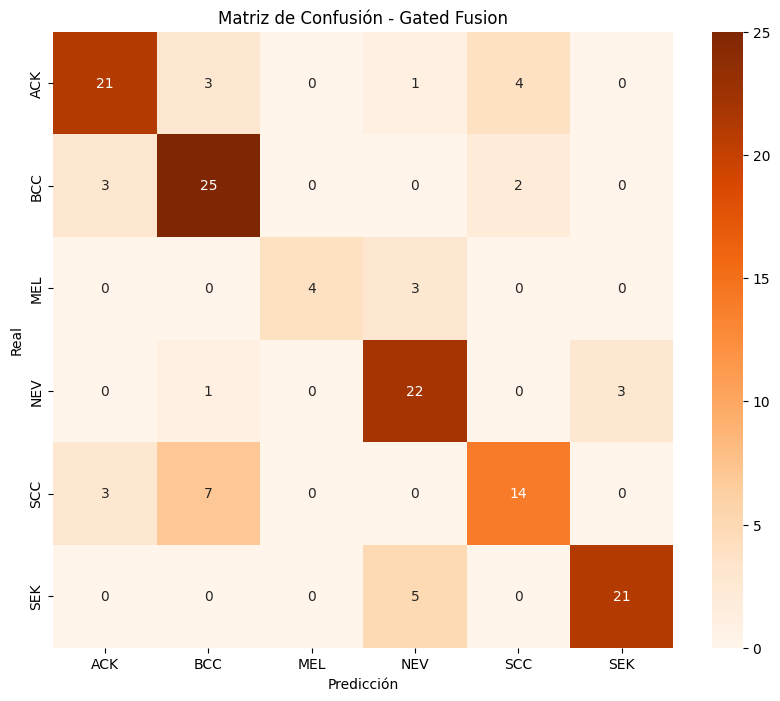

In [108]:
# =========================
# CELDA 12 - EVALUACIÓN FINAL (GATED FUSION)
# =========================
print("="*60)
print("GATED FUSION (TAB RF + IMG ENSEMBLE)")
print("="*60)
print("Accuracy:", accuracy_score(y_test, pred_final_test))
print("F1-macro:", f1_score(y_test, pred_final_test, average="macro"))
print("Kappa   :", cohen_kappa_score(y_test, pred_final_test))

print("\nClassification report:")
labels_eval = list(range(NUM_CLASSES))
print(classification_report(y_test, pred_final_test, labels=labels_eval, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, pred_final_test, labels=labels_eval)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names)
plt.title("Matriz de Confusión - Gated Fusion")
plt.xlabel("Predicción"); plt.ylabel("Real")
plt.show()


EXPLICABILIDAD Y ANÁLISIS DEL SISTEMA (RF + Gate + ImgEnsemble)

[0] Sanity checks
NUM_CLASSES: 6
N test: 142
Consultas ImgEnsemble: 70 (49.30%)

[1] RandomForest - Feature Importances (tabular)

Top-25 features (RF):


,feature,importance
0,age,0.114447
1,diameter_1,0.054698
2,diameter_2,0.050112
3,grew_FALSE,0.032920
4,fitspatrick,0.027616
5,biopsed_True,0.026211
6,itch_FALSE,0.024463
7,biopsed_False,0.023548
8,itch_TRUE,0.023218
9,changed_FALSE,0.021325


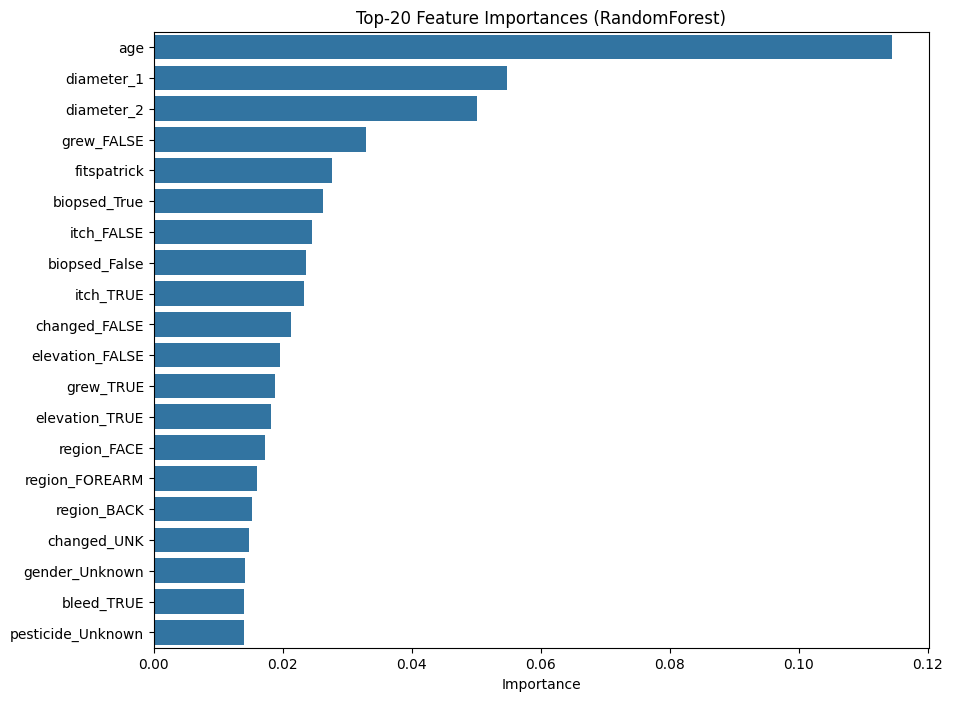

Top-5 acumulan: 27.98% de la importancia total
Top-10 acumulan: 39.86% de la importancia total
Top-20 acumulan: 56.04% de la importancia total
Top-30 acumulan: 68.75% de la importancia total
Top-50 acumulan: 89.26% de la importancia total

[2] Gate (LogReg) - Interpretación y activación

Resumen estadístico gate features:


,count,mean,std,min,25%,50%,75%,max
max_prob,142.0,0.577853,0.173279,0.262500,0.441250,0.550000,0.694875,0.947500
margin,142.0,0.329789,0.245495,0.000000,0.116875,0.303333,0.498750,0.927500
entropy,142.0,1.033715,0.381687,0.253639,0.681618,1.095359,1.345958,1.730765
gate_prob(RF_falla),142.0,0.455757,0.206295,0.069929,0.288054,0.496987,0.639201,0.771760



Media por grupo (gate=0 vs gate=1):


,max_prob,margin,entropy,gate_prob(RF_falla)
gate_decision,,,,
0,0.719872,0.523550,0.759021,0.280700
1,0.431776,0.130492,1.316258,0.635816



Coeficientes Gate LogReg (coef>0 => más prob de 'RF falla' => más consulta):


,feature,coef
2,entropy,0.329149
0,max_prob,-1.427438
1,margin,-2.612796


Intercept: 1.0953159600440803


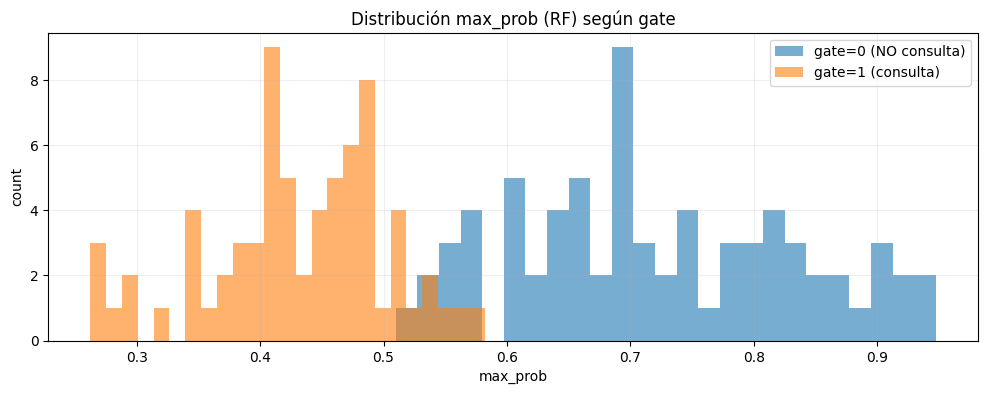

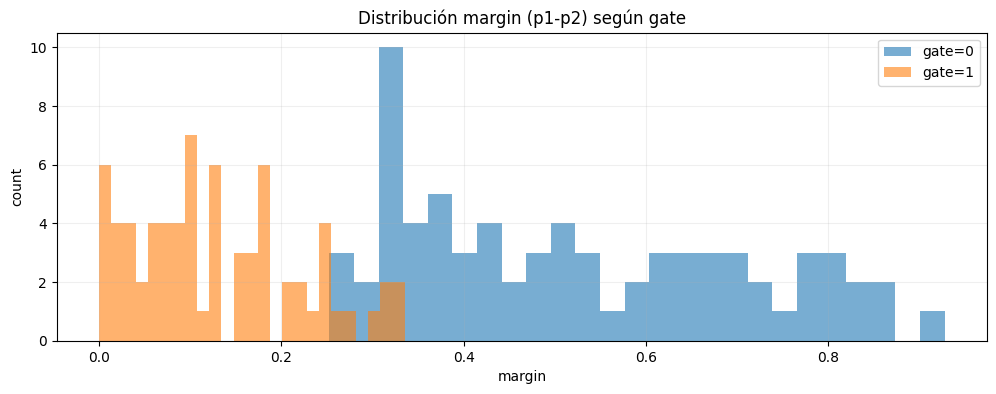

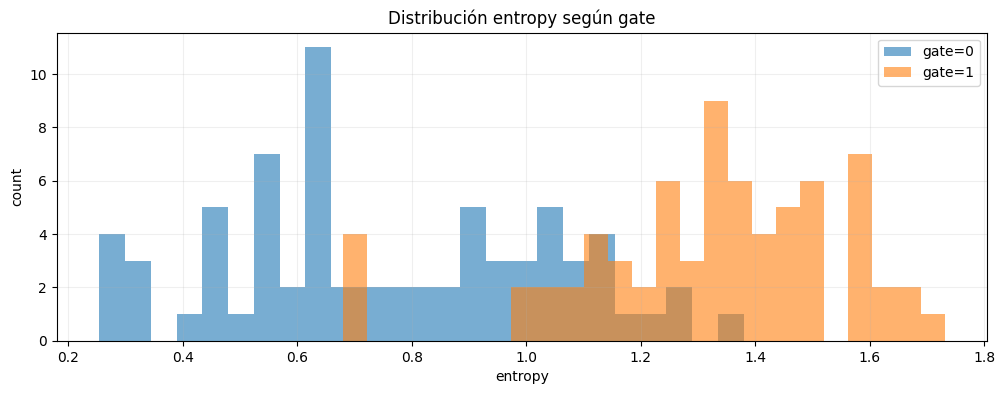


[3] Impacto de consultar ImgEnsemble: mejoras, correcciones y daños


,subset,n,acc,f1_macro
0,ALL - RF,142,0.683099,0.650564
1,ALL - SYSTEM,142,0.753521,0.747190
2,gate=0 - RF,72,0.833333,0.671673
3,gate=0 - SYSTEM,72,0.833333,0.671673
4,gate=1 - RF,70,0.528571,0.488185
5,gate=1 - SYSTEM,70,0.671429,0.674808



En subset gate=1 (consultas):
  Correcciones (RF mal -> SYSTEM bien): 20  (28.57%)
  Daños       (RF bien -> SYSTEM mal): 10    (14.29%)
  Ambos bien  : 27 (38.57%)
  Ambos mal   : 13 (18.57%)

Cambio en confianza max_prob (SYSTEM - RF):
  mean: 0.03269824836767416 | median: 1.1920928910669204e-08
  mean (gate=1): 0.06633073028609866
  mean (gate=0): 2.0580947686828685e-09


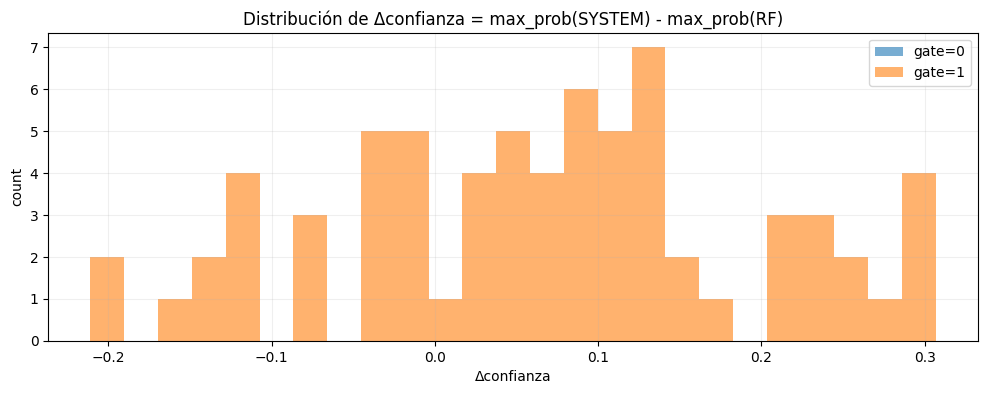


[4] Impacto por clase (en gate=1)


,class,n_gate1,acc_RF,acc_SYSTEM,delta_acc
5,SEK,6,0.166667,0.666667,0.500000
2,MEL,6,0.333333,0.666667,0.333333
1,BCC,18,0.500000,0.777778,0.277778
3,NEV,13,0.615385,0.846154,0.230769
4,SCC,16,0.687500,0.625000,-0.062500
0,ACK,11,0.545455,0.363636,-0.181818



[5] Ejemplos para inspección (corregidos vs dañados, gate=1)

🔧 Top corregidos (RF mal -> SYSTEM bien):


,i,img_id,y_true,RF_pred,SYS_pred,gate_prob,RF_maxprob
0,0,PAT_492_4723_890.png,ACK,SEK,ACK,0.553008,0.482500
1,19,PAT_265_1371_303.png,SEK,ACK,SEK,0.680437,0.400000
2,22,PAT_462_896_893.png,BCC,SCC,BCC,0.631313,0.492500
3,23,PAT_972_1843_756.png,MEL,NEV,MEL,0.612075,0.457500
4,28,PAT_198_853_778.png,NEV,ACK,NEV,0.696313,0.350000
5,30,PAT_513_964_343.png,BCC,SCC,BCC,0.708141,0.370000
6,45,PAT_54_83_405.png,BCC,NEV,BCC,0.742462,0.342500
7,52,PAT_403_804_994.png,NEV,BCC,NEV,0.755172,0.267500
8,57,PAT_168_1486_97.png,BCC,ACK,BCC,0.737441,0.340000
9,59,PAT_1837_3608_851.png,NEV,SEK,NEV,0.514089,0.582500



⚠️ Top dañados (RF bien -> SYSTEM mal):


,i,img_id,y_true,RF_pred,SYS_pred,gate_prob,RF_maxprob
0,18,PAT_311_666_191.png,SCC,SCC,BCC,0.688109,0.4100
1,20,PAT_782_1493_140.png,ACK,ACK,SCC,0.558719,0.4800
2,29,PAT_214_329_70.png,BCC,BCC,ACK,0.557548,0.5175
3,31,PAT_839_1591_204.png,NEV,NEV,BCC,0.593536,0.4750
4,32,PAT_935_1785_530.png,SCC,SCC,BCC,0.572645,0.5075
5,65,PAT_873_1661_178.png,ACK,ACK,BCC,0.604829,0.4275
6,76,PAT_49_75_326.png,SCC,SCC,ACK,0.600622,0.4775
7,81,PAT_246_377_159.png,ACK,ACK,NEV,0.670264,0.3850
8,98,"PAT_962_1823_942.png, PAT_962_1823_857.png",BCC,BCC,ACK,0.658420,0.4125
9,140,PAT_537_1014_961.png,SCC,SCC,ACK,0.638657,0.4450



✅ Fin del análisis.


In [109]:
# =========================
# ÚLTIMA CELDA: EXPLICABILIDAD + ANÁLISIS DEL GATE + IMPACTO DEL ENSEMBLE
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

print("="*80)
print("EXPLICABILIDAD Y ANÁLISIS DEL SISTEMA (RF + Gate + ImgEnsemble)")
print("="*80)

# ---------------------------------------------------------------------
# 0) Sanity checks (variables correctas del pipeline)
# ---------------------------------------------------------------------
print("\n[0] Sanity checks")
print("NUM_CLASSES:", NUM_CLASSES)
print("N test:", len(y_test))

# En el pipeline bueno, esto se llama gate_called (0/1 por fila)
if "gate_called" in globals():
    n_calls = int(np.sum(gate_called))
    print("Consultas ImgEnsemble:", n_calls, f"({n_calls/len(y_test)*100:.2f}%)")
else:
    print("⚠️ No encuentro 'gate_called'. ¿Se llama distinto? "
          "Revisa la celda de inferencia gated.")

# Predicciones y probabilidades finales correctas
# (en tu pipeline eran pred_final_test y p_final_test)
if "pred_final_test" in globals():
    pred_sys = np.array(pred_final_test)
else:
    raise NameError("No existe 'pred_final_test'. ¿Has ejecutado la celda de inferencia gated?")

if "p_final_test" in globals():
    p_final = np.array(p_final_test)
else:
    p_final = None

# Baseline tabular (RF)
pred_rf = np.array(pred_tab_test)
p_tab = np.array(p_tab_test)
y = np.array(y_test)

# Para el gate: probabilidad de consultar (pg) no la guardabas antes.
# Si quieres análisis completo, la reconstruimos aquí:
def _entropy(p, eps=1e-12):
    p = np.clip(p, eps, 1.0)
    return -np.sum(p * np.log(p), axis=1)

max_prob = p_tab.max(axis=1)
sorted_p = np.sort(p_tab, axis=1)
margin = sorted_p[:, -1] - sorted_p[:, -2] if p_tab.shape[1] >= 2 else np.zeros(len(p_tab))
ent = _entropy(p_tab)
Xg_test = np.vstack([max_prob, margin, ent]).T  # (N,3)

gate_prob_test = gate.predict_proba(Xg_test)[:, 1]  # P(RF_falla)
gate_decision  = (gate_prob_test >= GATE_THRESHOLD).astype(int)

# ---------------------------------------------------------------------
# 1) Feature importance del RandomForest
# ---------------------------------------------------------------------
print("\n" + "="*80)
print("[1] RandomForest - Feature Importances (tabular)")
print("="*80)

if hasattr(rf_final, "feature_importances_"):
    importances = rf_final.feature_importances_
    fi_df = pd.DataFrame({"feature": tab_cols, "importance": importances})
    fi_df = fi_df.sort_values("importance", ascending=False).reset_index(drop=True)

    print("\nTop-25 features (RF):")
    display(fi_df.head(25))

    plt.figure(figsize=(10, 8))
    topn = 20
    sns.barplot(data=fi_df.head(topn), y="feature", x="importance", orient="h")
    plt.title(f"Top-{topn} Feature Importances (RandomForest)")
    plt.xlabel("Importance")
    plt.ylabel("")
    plt.show()

    fi_df["cum"] = fi_df["importance"].cumsum()
    for k in [5, 10, 20, 30, 50]:
        if k <= len(fi_df):
            print(f"Top-{k} acumulan: {fi_df.loc[k-1,'cum']*100:.2f}% de la importancia total")
else:
    print("⚠️ rf_final no tiene feature_importances_ (raro en RF).")

# ---------------------------------------------------------------------
# 2) Gate (LogReg) - interpretación
# ---------------------------------------------------------------------
print("\n" + "="*80)
print("[2] Gate (LogReg) - Interpretación y activación")
print("="*80)

gate_feat_test = pd.DataFrame({
    "max_prob": max_prob,
    "margin": margin,
    "entropy": ent,
    "gate_prob(RF_falla)": gate_prob_test,
    "gate_decision": gate_decision.astype(int)
})

print("\nResumen estadístico gate features:")
display(gate_feat_test[["max_prob","margin","entropy","gate_prob(RF_falla)"]].describe().T)

print("\nMedia por grupo (gate=0 vs gate=1):")
display(gate_feat_test.groupby("gate_decision")[["max_prob","margin","entropy","gate_prob(RF_falla)"]].mean())

if hasattr(gate, "coef_"):
    coef = gate.coef_.ravel()
    intercept = float(gate.intercept_[0])
    coef_df = pd.DataFrame({
        "feature": ["max_prob","margin","entropy"],
        "coef": coef
    }).sort_values("coef", ascending=False)
    print("\nCoeficientes Gate LogReg (coef>0 => más prob de 'RF falla' => más consulta):")
    display(coef_df)
    print("Intercept:", intercept)

# Distribuciones
plt.figure(figsize=(12,4))
plt.hist(gate_feat_test.loc[gate_feat_test["gate_decision"]==0,"max_prob"], bins=25, alpha=0.6, label="gate=0 (NO consulta)")
plt.hist(gate_feat_test.loc[gate_feat_test["gate_decision"]==1,"max_prob"], bins=25, alpha=0.6, label="gate=1 (consulta)")
plt.title("Distribución max_prob (RF) según gate")
plt.xlabel("max_prob"); plt.ylabel("count"); plt.legend(); plt.grid(True, alpha=0.2)
plt.show()

plt.figure(figsize=(12,4))
plt.hist(gate_feat_test.loc[gate_feat_test["gate_decision"]==0,"margin"], bins=25, alpha=0.6, label="gate=0")
plt.hist(gate_feat_test.loc[gate_feat_test["gate_decision"]==1,"margin"], bins=25, alpha=0.6, label="gate=1")
plt.title("Distribución margin (p1-p2) según gate")
plt.xlabel("margin"); plt.ylabel("count"); plt.legend(); plt.grid(True, alpha=0.2)
plt.show()

plt.figure(figsize=(12,4))
plt.hist(gate_feat_test.loc[gate_feat_test["gate_decision"]==0,"entropy"], bins=25, alpha=0.6, label="gate=0")
plt.hist(gate_feat_test.loc[gate_feat_test["gate_decision"]==1,"entropy"], bins=25, alpha=0.6, label="gate=1")
plt.title("Distribución entropy según gate")
plt.xlabel("entropy"); plt.ylabel("count"); plt.legend(); plt.grid(True, alpha=0.2)
plt.show()

# ---------------------------------------------------------------------
# 3) Impacto del ensemble (comparación RF vs sistema)
# ---------------------------------------------------------------------
print("\n" + "="*80)
print("[3] Impacto de consultar ImgEnsemble: mejoras, correcciones y daños")
print("="*80)

idx_gate1 = np.where(gate_decision == 1)[0]
idx_gate0 = np.where(gate_decision == 0)[0]

def metrics(y_true, y_pred, name):
    return {
        "subset": name,
        "n": len(y_true),
        "acc": accuracy_score(y_true, y_pred) if len(y_true)>0 else np.nan,
        "f1_macro": f1_score(y_true, y_pred, average="macro") if len(y_true)>0 else np.nan
    }

rows = []
rows.append(metrics(y, pred_rf, "ALL - RF"))
rows.append(metrics(y, pred_sys, "ALL - SYSTEM"))

rows.append(metrics(y[idx_gate0], pred_rf[idx_gate0], "gate=0 - RF"))
rows.append(metrics(y[idx_gate0], pred_sys[idx_gate0], "gate=0 - SYSTEM"))

rows.append(metrics(y[idx_gate1], pred_rf[idx_gate1], "gate=1 - RF"))
rows.append(metrics(y[idx_gate1], pred_sys[idx_gate1], "gate=1 - SYSTEM"))

impact_df = pd.DataFrame(rows)
display(impact_df)

rf_correct_gate1  = (pred_rf[idx_gate1] == y[idx_gate1])
sys_correct_gate1 = (pred_sys[idx_gate1] == y[idx_gate1])

n_gate1 = len(idx_gate1)
corrected = np.sum((~rf_correct_gate1) & (sys_correct_gate1))
damaged   = np.sum((rf_correct_gate1) & (~sys_correct_gate1))
both_wrong = np.sum((~rf_correct_gate1) & (~sys_correct_gate1))
both_right = np.sum((rf_correct_gate1) & (sys_correct_gate1))

print("\nEn subset gate=1 (consultas):")
print(f"  Correcciones (RF mal -> SYSTEM bien): {corrected}  ({corrected/max(1,n_gate1)*100:.2f}%)")
print(f"  Daños       (RF bien -> SYSTEM mal): {damaged}    ({damaged/max(1,n_gate1)*100:.2f}%)")
print(f"  Ambos bien  : {both_right} ({both_right/max(1,n_gate1)*100:.2f}%)")
print(f"  Ambos mal   : {both_wrong} ({both_wrong/max(1,n_gate1)*100:.2f}%)")

# Cambio de confianza: max prob sistema vs RF (si hay p_final)
if p_final is not None:
    max_final = p_final.max(axis=1)
    delta_conf = max_final - max_prob
    print("\nCambio en confianza max_prob (SYSTEM - RF):")
    print("  mean:", float(delta_conf.mean()), "| median:", float(np.median(delta_conf)))
    print("  mean (gate=1):", float(delta_conf[idx_gate1].mean()) if len(idx_gate1)>0 else np.nan)
    print("  mean (gate=0):", float(delta_conf[idx_gate0].mean()) if len(idx_gate0)>0 else np.nan)

    plt.figure(figsize=(12,4))
    plt.hist(delta_conf[idx_gate0], bins=25, alpha=0.6, label="gate=0")
    plt.hist(delta_conf[idx_gate1], bins=25, alpha=0.6, label="gate=1")
    plt.title("Distribución de Δconfianza = max_prob(SYSTEM) - max_prob(RF)")
    plt.xlabel("Δconfianza"); plt.ylabel("count"); plt.legend(); plt.grid(True, alpha=0.2)
    plt.show()

# ---------------------------------------------------------------------
# 4) Impacto por clase (en gate=1)
# ---------------------------------------------------------------------
print("\n" + "="*80)
print("[4] Impacto por clase (en gate=1)")
print("="*80)

per_class_rows = []
for c in range(NUM_CLASSES):
    idx_c = idx_gate1[y[idx_gate1] == c]
    if len(idx_c) == 0:
        continue
    acc_rf  = accuracy_score(y[idx_c], pred_rf[idx_c])
    acc_sys = accuracy_score(y[idx_c], pred_sys[idx_c])
    per_class_rows.append({
        "class": class_names[c] if c < len(class_names) else str(c),
        "n_gate1": len(idx_c),
        "acc_RF": acc_rf,
        "acc_SYSTEM": acc_sys,
        "delta_acc": acc_sys - acc_rf
    })

per_class_df = pd.DataFrame(per_class_rows).sort_values("delta_acc", ascending=False)
display(per_class_df)

# ---------------------------------------------------------------------
# 5) Ejemplos "corregidos" y "dañados" (gate=1)
# ---------------------------------------------------------------------
print("\n" + "="*80)
print("[5] Ejemplos para inspección (corregidos vs dañados, gate=1)")
print("="*80)

def show_examples(kind="corrected", k=10):
    if kind == "corrected":
        mask = (~(pred_rf==y)) & ((pred_sys==y)) & (gate_decision==1)
    else:
        mask = ((pred_rf==y)) & (~(pred_sys==y)) & (gate_decision==1)

    idxs = np.where(mask)[0][:k]
    rows = []
    for i in idxs:
        rows.append({
            "i": int(i),
            "img_id": test_df.loc[i, "img_id"],
            "y_true": class_names[int(y[i])] if int(y[i]) < len(class_names) else int(y[i]),
            "RF_pred": class_names[int(pred_rf[i])] if int(pred_rf[i]) < len(class_names) else int(pred_rf[i]),
            "SYS_pred": class_names[int(pred_sys[i])] if int(pred_sys[i]) < len(class_names) else int(pred_sys[i]),
            "gate_prob": float(gate_prob_test[i]),
            "RF_maxprob": float(max_prob[i])
        })
    return pd.DataFrame(rows)

print("\n🔧 Top corregidos (RF mal -> SYSTEM bien):")
display(show_examples("corrected", k=12))

print("\n⚠️ Top dañados (RF bien -> SYSTEM mal):")
display(show_examples("damaged", k=12))

print("\n✅ Fin del análisis.")
